<a href="https://colab.research.google.com/github/Joaco3101/CFD-Flow-around-Obstacle/blob/main/Copy_of_ME_415_(S25)_DP1_Warm_up_Part_2_Fixed_Heat_Sink_Design_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: <font color='Red'>Dobule Click to Edit</font>

---

<font color='Red'> After you complete this assignment, download it as a *.ipynb file and upload to gradescope. For part 1, upload a photo of your resistance network directly to gradescope. For part 7, type your answers directly into gradescope.

---


# **Overview:**
The goal of this exercise is to design a heat sink to effectivly dissipate heat in for a vertical upflow configuration while keeping the system light weight.


*Optimization Function*:  The optimization function is the figure of merit:
$$\text{FOM} = \frac{1}{m_{HS} R_{HS}}$$

where $m_{HS}$ is the total mass of the heat sink and $R_{HS}$ are the thermal resitances for a given inlet flow velocity of $V$.


# System Parameters
The test chamber is shown in the Figure 1 below along wiht the baseplate above which your heat sink geometry will be designed.

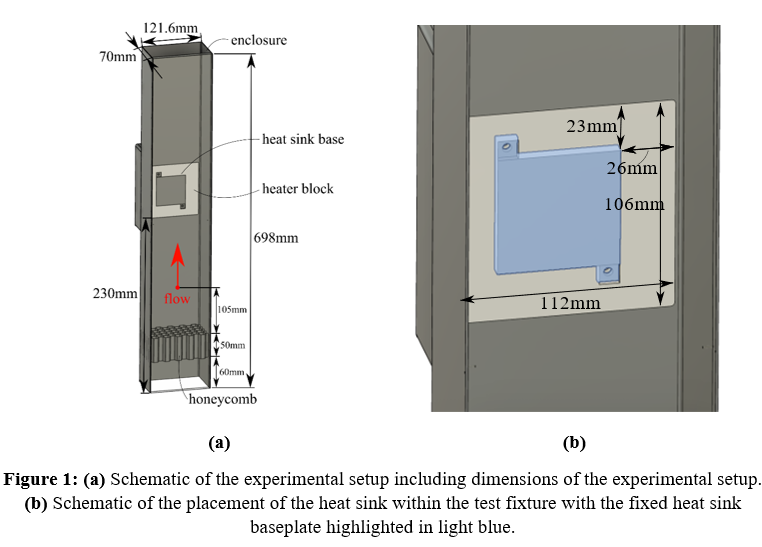!

# Design Constraints:

Each heat sink must start with a 60 mm x 60 mm x 6.25 mm base plate as shown in Figure 1b (above). You must design a heat sink to occupy the space above the baseplate. The maximum height is limited to 38 mm.

Initially, the material is limited to stainless steel with $k\approx 15$ W/(m K) and $\rho \approx$ 7800 kg/m$^3$. But we will also explore other mateirals.

---

# **Caution: Major Assumptions / Simplifications:**
- **Neglect Parasitic heat loss:** The heater power coming into the electrical heaters is not the power that is dissipated through the heat sink: some is lost through the insulation and housing surrounding the heater section: $q_{input} = q_{hs} + q_{loss}$, where $q_{hs}$ is the (desired) heat transfer through the heat sink and $q_{loss}$ is the heat loss through the insulation and housing.

- **Neglect contact resistance from heater base to the base of the heat sink**: In the competition, the hottest temperature is measured in the aluminum block holding the heaters, but for this simple analysis, we will assume we can measure the temperature on the base of the heat sink.

With these two assumptions, we will focus on optimizing the system assuming a heat sink base temperature $T_b$ and neglecting losses through the housing or the temperature drop between the heater block and the heat sink base. Therefore, our goal is to maximize the heat flow for a fixed $\Delta T = T_b-T_{amb}$ (while minimizing the mass).

In [ ]:
T_b = 95  #[C] Heat sink base temperature


- **Neglect fluid flow bypass:** Some of the fluid flow can bypass the heat sink in the space between the heat sink and the system boundaries. Thus, if we assume the nominal flow velocities, this may be an overestimation of the flow rates near the finned structures. In contrast, the heat sinks blocks a portion of the flow cross-section, so in that region following conservation of mass, there could be an incrased free stream velocity due to the reduced area for flow. In any case, we will assume a uniform inlet velocity of 1 and 5 m/s without considering the impact of bypassing the heat sink.

---

# Setup Python including CoolProp:




In [ ]:
#@title
# Set up the python script
# import required modules

#Numerical Math
import math # math functions
import numpy as np # numerical math
from numpy import *

#Import contsants.
from scipy.constants import pi
from scipy.constants import g   #standard acceleration of gravity [m/s^2]

#plotting
params = {'legend.fontsize': 'large',
          'figure.figsize': (8, 6),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
import matplotlib.pyplot as plt
plt.rcParams.update(params)

#!pip install pandas
import pandas as pd

!pip install CoolProp
import CoolProp
from CoolProp.CoolProp import PropsSI
from CoolProp.CoolProp import PhaseSI


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 38.2 MB/s eta 0:00:00


##Known Parameters:

First input the known geometrical parameters

In [ ]:
Th = 6.25/1000  #[m] HS Base thickness
W = 60/1000     #[m] Base width
D = 60/1000     #[m] Base depth
H_max = 38/1000     #[m] Maximum Fin height

We will first assume a uniform inlet velocity in the range of 5 to 40 m/s and an ambient temperature of approximately $T_{amb}$ = 30$^o$C.

In [ ]:
V = np.linspace(5,40,36) #[m/s] flow velocities
T_amb = 30  #[C] ambient temperature

In the steady state thermal problem, we only need the thermal conductvity of the printed metal, which we will first assume is that of stainless steel $k_{ss} \approx 15$ W/(m K).  For the figure of merit, we also need the density of printed metal, which we will estimate as 7800 kg/m$^3$.

Here we will use ```km``` and ```rhom``` for these property to separate them from the air properties, which we will designate as ```ka``` and ```rho```.

In [ ]:
km = 15  #[W/m-K] Printed metal conductivity
rhom = 7800 #[kg/m^3] Printed metal density

---
# Baseline Case: Straight Fin Heat Sink



Let's start by analyzing a simple straight fin heat sink.  We'll put some

1.   List item
2.   List item

initial guesses in on the number of fins (with 1 less channel for airflow than there are fins) and the height. As a starting point, let's assume the fin spacing and thickness are equal and that the first and last fin align with the base plate edge.

We will pick some initial parameters, based in part on the heat sink shown here:

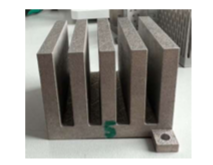

In [ ]:
N = 5            #[-] Number of fins
Nc = N-1          #[-] Number of channels (one less channel than fin)
H = 38/1000       #[m] Height (starting assumption = max height)
s = W/(N+Nc)      #[m] Fin spacing (or channel width)
t = W/(N+Nc)      #[m] Fin thickness

---
##<font color='Green'>**Problem 1: Sketch the Thermal Resistance Network**
<font color='Green'>**Sketch the thermal resistance diagram from the bottom surface temperature of the heat sink ($T_b$) to the ambient air temperature ($T_\infty$) through the heat sink breaking the heat sink up into the finned surfaces and the unfinned base (that is, the bottoms of the channels for airflow).** Identify the required equations for each resistance that composes the heat sink.

* <font color='Green'>Make sure to include the resistance due to the finite thickness of the required base of the heat sink in your analysis
* <font color='Green'>For the finned portion of the heat sink include 1 resistor for each fin and 1 resistor for the unfinned base.
* <font color='Green'>Recall we are neglecting parasitic losses through the housing and the connection from the heater block to the base. Instead, start your diagram at the bottom surface of the heat sink baseplate itself. We'll call this $T_{b}$


<font color='Magenta'>Upload an image of your resistance network when you submit the assignment on gradescope


---

## Determine the convection coefficient

Now we want to find the value of $h$ for each flow velocity.
To do so, we follow this procedure:
- Find fluid properties based on the mean temperature $\overline{T}$ of the fluid
- Calculate relevant fluid properties from CoolProp
- Decide if natural convection is important
- Select an appropriate correlation
- Calculate $Re$, $Nu$, and then $h$

###**Find the fluid properties for each case:**




We'll use CoolProp to find the fluid properties, but we generally need to estimate the film temperature $T_f = \frac{T_b+T_{amb}}{2}$.

In [ ]:
T_f = (T_b + T_amb)/2 + 273.15  #[K]
print(f'T_f = {T_f:1.1f} K')

T_f = 335.6 K


####Calculate Fluid Propeties

Let's now use CoolProp to find the fluid properties at ambient pressure and film temperature ($T_f$). Since we assumed a specific $T_b$ and thus $T_f$, we have single values for each air property.

In [ ]:
P_atm = 101325 #[Pa] Ambient pressure
mu=CoolProp.CoolProp.PropsSI("V", "T", T_f, "P", P_atm, "Air")
ka=CoolProp.CoolProp.PropsSI("L", "T",T_f, "P", P_atm, "Air")
cp=CoolProp.CoolProp.PropsSI("CP0MASS", "T", T_f, "P", P_atm, "Air")
rho=CoolProp.CoolProp.PropsSI("D", "T", T_f, "P", P_atm, "Air")
nu=mu/rho
alpha=ka/(rho*cp)
Pr = nu/alpha

### Determine flow regime / conditions

While the fan provides forced flow over the heat sink, heating in the the vertical flat plate arrangement can cause additional natural convection flow. We will first calculate the $Re$ and $Gr$ numbers to weigh the relative importance:

---
####<font color='Green'>**Problem 2: Show that natural convections are not significant by plotting the ratio of the Grashof Number  and the square of the Reynolds number $(Gr/Re^2)$ as a function of velocity.**
- <font color='Green'>Recall we are assuming the velocity is uniform at the inlet of the heat sink and neglecting the bypass flow ($U_\infty$ is our variable ```V```).
- <font color='Green'>Assume  the characteristic length scale in each case is $W$, which is the sidelength of the heat sink base that is the path length in the flow direction.
- Recall that in the Grashof number, the term $\beta = 1/T_f$

In [ ]:
# These lines add the characteristic lengthscale and the gravitational accelration constant
Lc = W  # Assume flow is in the vertical direction aligned with the Width of the heat sink
g = 9.81 #[m/s^2]

<font color='Magenta'> Now, define the equations for $Re_x$ and $Gr_x$ in terms of known variables. Add your equations to the lines below. Then hit the "play" button to the left of the  code block to generate  the plot

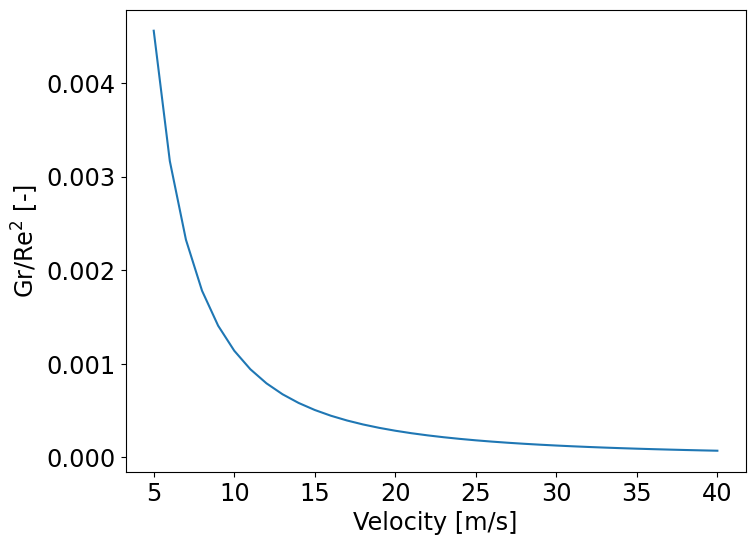

Forced Convection dominates - Ok to proceed


In [ ]:
beta = 1/T_f
Re = V*Lc/nu       #[-] Reynolds number at x = W
Gr=  g*beta*(T_b-T_amb)*Lc**3/nu**2       #[-] Grashof number at x = W
Ratio = Gr/Re**2

plt.plot(V,Ratio)
plt.xlabel('Velocity [m/s]')
plt.ylabel('Gr/Re$^2$ [-]')
plt.show()


if Ratio.max() >= 1:
  print('Warning: Natural Convection is important')
else:
  print('Forced Convection dominates - Ok to proceed')

---

####<font color='Green'>**Problem 3: Estimate thickness of the thermal and velocity boundary layers at the end of the channels ($x = W$) to confirm that the flow along the plates can be considered as external flow.** In other words, prove that $\left( \text{channel width}/2 < \text{boundary layer thickness}\right)$

<font color='Magenta'>Step 1: Evaluate the Reynolds numbers and compare to the cutoff for transition to turbulence ```Re_c```. Add the critical Reynolds number to the code below. Then run the code block.

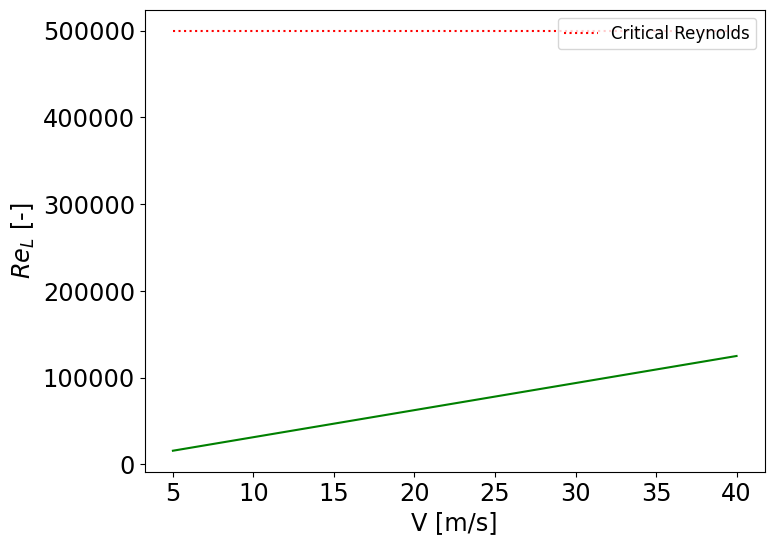

Laminar flow - Ok to proceed


In [ ]:
Re_c = 5e5    #[-] Critical Reynolds number for transition to turbulence
plt.plot(V,Re,'g')
plt.plot(np.array([min(V),max(V)]),np.array([Re_c,Re_c]),':r',label='Critical Reynolds')
plt.legend(loc=1)
plt.xlabel('V [m/s]')
plt.ylabel('$Re_{L}$ [-]')
plt.show()


if Re.max() >= Re_c:
  print('Warning: Turbulent flow important')
else:
  print('Laminar flow - Ok to proceed')

<font color='magenta'> Step 2: Based on the comparison, input the appropriate equations for the velocity (```delta_v```) and thermal (```delta_t```) boundary layer thickesses. Then run the codeblock.

The Reynolds numbers are below the cutoff for transition to turbulence: $Re_c = 5\times10^5$. Thus, the flow let's assume the flow to be laminar. Then to calculate the boundary layer thickness in the laminar regime, we can use $\frac{\delta_{velocity}}{x} \approx \frac{5}{\sqrt{Re_x}}$, where $x=W$ here. For the thermal boundary layer thickness, $\frac{\delta_{thermal}}{\delta_{velocity}} \approx Pr^{-1/2}$

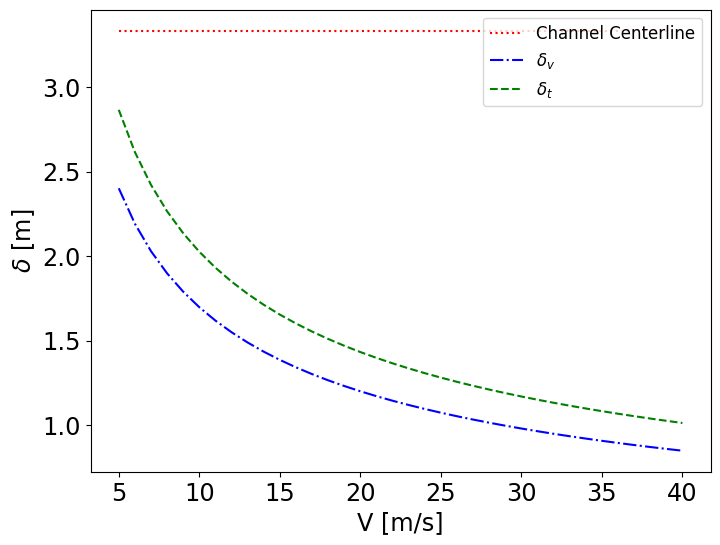

Large enough channel - Ok to proceed


In [ ]:
delta_v = W*5/sqrt(Re)        #[m] velocity bouldary layer thickness at x = W
delta_t = delta_v*Pr**(-1/2)        #[m] thermal bouldary layer thickness at x = W

plt.plot(np.array([min(V),max(V)]),np.array([s/2,s/2])*1000,':r',label='Channel Centerline')
plt.plot(V,delta_v*1000,'b-.',label='$\delta_v$')
plt.plot(V,delta_t*1000,'g--',label='$\delta_t$')
plt.legend(loc=1)
plt.xlabel('V [m/s]')
plt.ylabel('$\delta$ [m]')
plt.show()


if max(delta_v.max(),delta_t.max()) >= s/2:
  print('Warning: Boundary layers merge for some velocities')
else:
  print('Large enough channel - Ok to proceed')

Given these results $\left( \frac{s}{2} > \delta_v, \delta_t \right)$ for all velocities, we will assume the flow can be considered as external flow.

---
### Identify the appropriate correlation for $h$
Now we've identiifed the flow regimes (Laminar flow over flat plates) and can select appropriate correlations.

---
#### <font color='green'> **Problem 4: Estimate of the convection coefficient for each velocity based on appropriate correlation(s)**. The summary tables for Chapter 7 and/or Chapter 8 in the Incropera and Dewitt textbook are a helpful references.

<font color='magenta'> Insert appropriate expressions for the Nusselt number ```Nu``` and the convection coefficient ```h``` below, then run this code block:

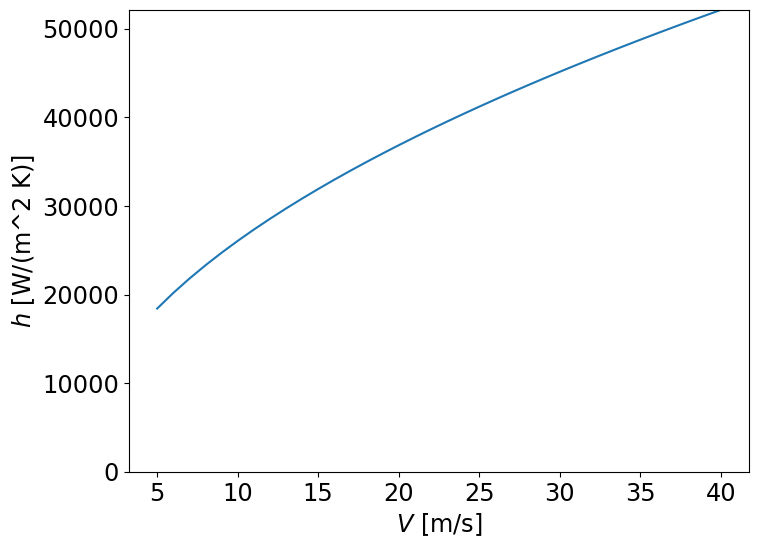

In [ ]:
Nu = 0.664*sqrt(Re)*Pr**(1/3)       #[-] Nusselt number
h = km/Lc*Nu     #[W/(m^2 K)] Convection Coefficient
plt.plot(V,h)
plt.xlabel('$V$ [m/s]')
plt.ylabel('$h$ [W/(m^2 K)]')
plt.ylim([0,h.max()])
plt.show()

---

### Calculate individual fin efficiency and individual fin resistance
To calculate the heat sink resistance, first need to find the individual fin restances and we can do this using the concept of fin efficiency.


---
#### <font color='green'> ***Problem 5: Calculate the fin resistance*** for 1 fin. Assume each fin is a straight rectangular fin as shown in the photo above. You may eglect any differences in the flow adjacent to surfaces of the end fins compared to the center fins.

<font color='magenta'> Step 1: Find an equation for the efficiency of a single rectangular straight fin. Enter expressions for each term in the code block below. Then, run the code block.

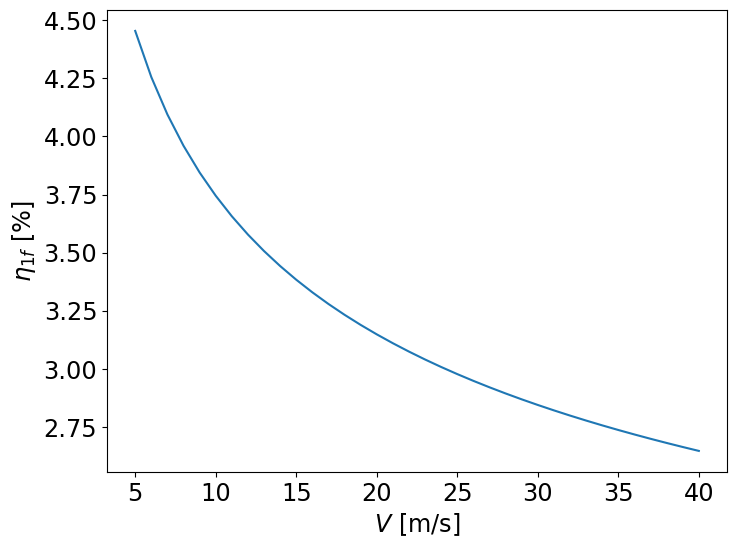

In [ ]:
Lc = (H - Th) + t/2    #[m] characteristic length of the fin
P = 2*W +2*t         #[m] wetted perimeter of the fin
Ac = t*W        #[m] cross-sectional area of the fin (in the axial direction)
m = sqrt(h*P/(km*Ac))      #[1/m] non-dimensional fin parameter
eta_1f = np.tanh(m*Lc) / (m*Lc)     #[-] Fin efficiency

plt.plot(V,eta_1f*100)
plt.xlabel('$V$ [m/s]')
plt.ylabel('$\eta_{1f}~[\%]$')
plt.show()

<font color='magenta'> Step 2: Find an equation for the resistance of a single rectangular straight fin. Enter expressions for each term in the code block below. Then, run the code block.

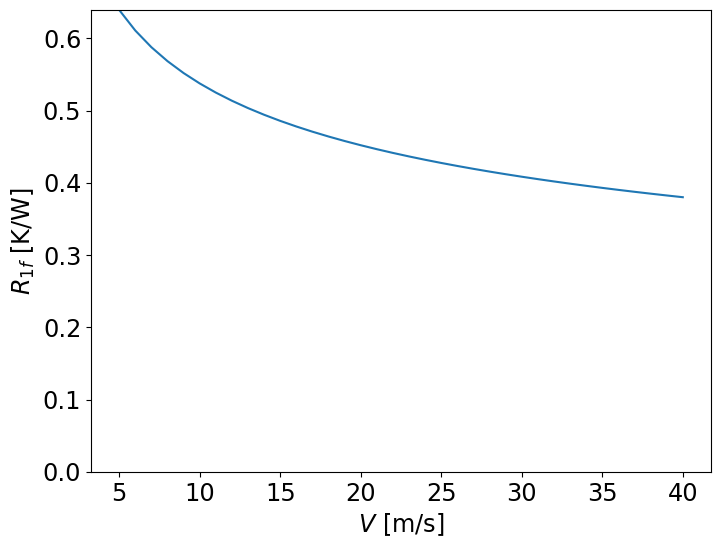

In [ ]:
Af = W*(H-Th)
R_1f = 1/(Af*eta_1f*h)

plt.plot(V,R_1f)
plt.xlabel('$V$ [m/s]')
plt.ylabel('$R_{1f}$ [K/W]')
plt.ylim([0,R_1f.max()])
plt.show()

---
## <font color='green'> **Problem 6: Calculate the heat sink resistance**

<font color='green'> Now we want to find the total resistance of the heat sink (consult your diagram from problem 1). There are 3 components of interest:

1. Conduction through the heat sink base.
2. Convection from the un-finned portion of the base.
3. Conduction-convection through the fins themself.


<font color='magenta'> Step 6.1: Find an equation for the thermal resistance of the heat sink base assuming 1D heat transfer through the base. Enter expressions for each term in the code block below. Then, run the code block.


In [ ]:
R_base = Th / (km*W**2)
print(f'Base thermal resistance: R_base = {R_base:1.3f} K/W')

Base thermal resistance: R_base = 0.116 K/W


<font color='magenta'> Step 6.2: Find an equation for the thermal resistance of the unfinned base base assuming the same $h$ as the fin side walls. Enter expressions for each term in the code block below. Then, run the code block.


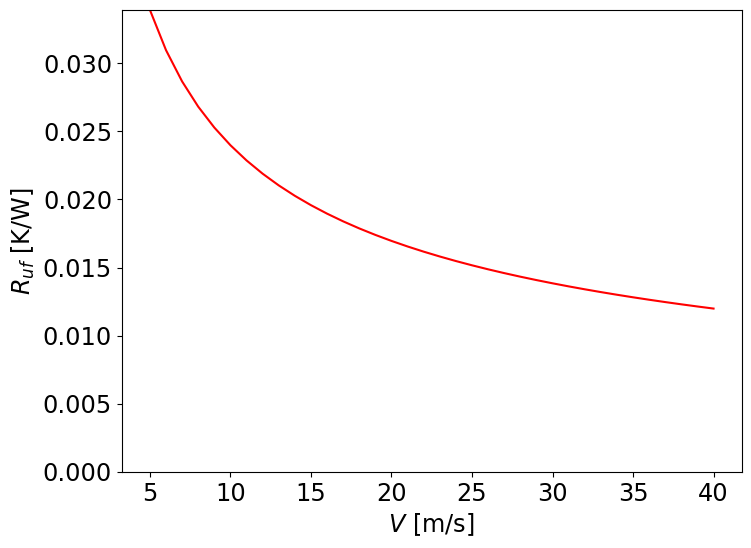

In [ ]:
A_uf = s*Nc*W       #[m^2] Unfinned base area. Also equal to W*D-N*W*t
R_uf = 1/(h*A_uf)   #[K/W] Resistance of the unfinned base via convection
plt.plot(V,R_uf,'r',label='$R_{uf}$')
plt.xlabel('$V$ [m/s]')
plt.ylabel('$R_{uf}$ [K/W]')
plt.ylim([0,R_uf.max()])
plt.show()

<font color='magenta'> Step 6.3: Based on the series and parallel combinations of flow paths, determine the total resistance from $T_b$ to $T_{amb}$. Enter expressions for each term in the code block below. Then, run the code block.

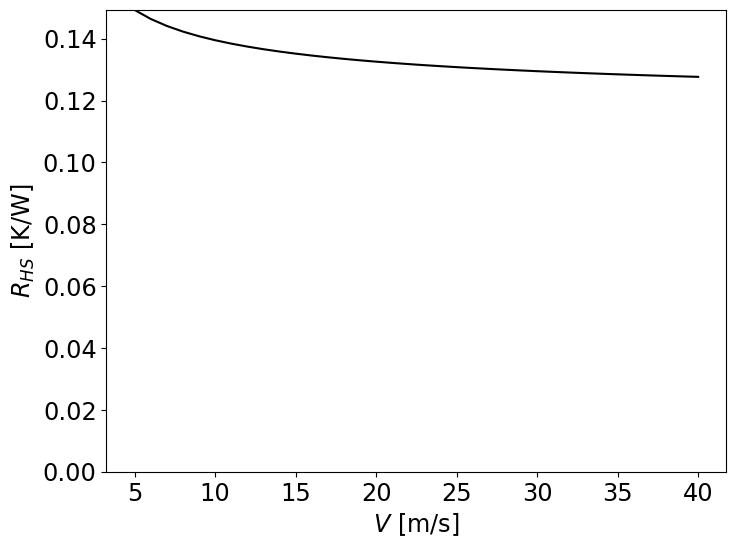

In [ ]:
R_HS = R_base + (1/(N*R_1f) + 1/R_uf)**-1
plt.plot(V,R_HS,'k',label='$R_{HS}$')
plt.xlabel('$V$ [m/s]')
plt.ylabel('$R_{HS}$ [K/W]')
plt.ylim([0,R_HS.max()])
plt.show()

---
## Calculate the Figure of merit across this range of flow velocities:


Run the code block below to generate a curve of the FOM vs. flow velocity. With the straigh fin heat sink the mass can be determined from volume as:
$$m_{HS} = \rho_m V_{HS}$$
and
$$V_{HS} = (W D~Th) + N (W~H~t)$$

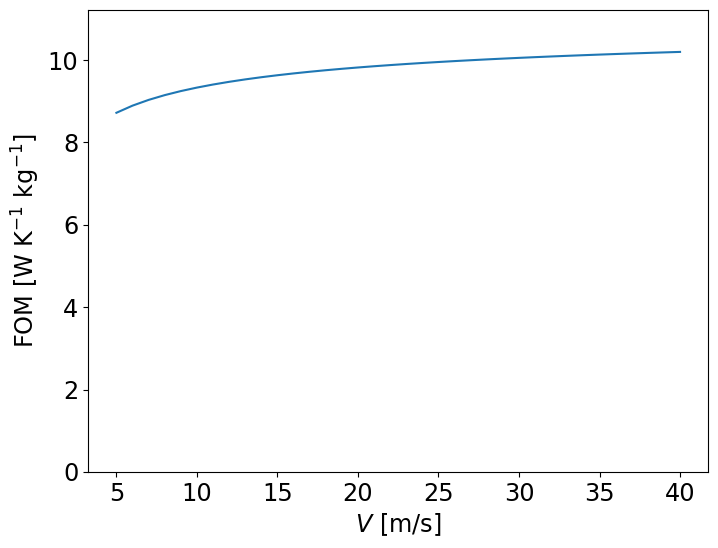

In [ ]:
V_HS = (W*D*Th) + (W*H*t*N)
m_HS = rhom * V_HS
FOM = 1/(R_HS*m_HS)


plt.plot(V,FOM)
plt.xlabel('$V$ [m/s]')
plt.ylabel('FOM [W K$^{-1}$ kg$^{-1}$]')
plt.ylim([0,max(FOM)*1.1])
plt.show()

---
## Calculate heat flow rates

Although not needed to determine the FOM, we can also calculate the temperature rise at the base of the heat sink for Ohm's Law: $\Delta T = T_b - T_{amb} = q_{HS} R_{HS}$, where $q_{HS}$ is the total input power assuming no parasitic losses.

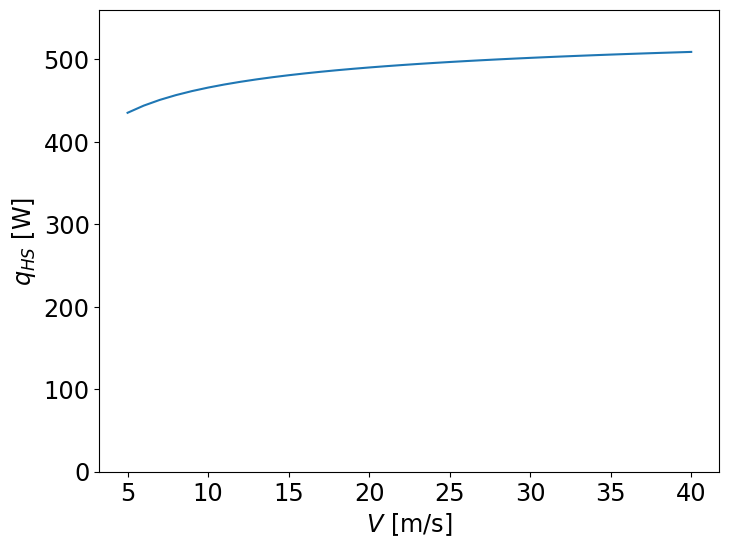

In [ ]:
q_HS = (T_b-T_amb)/R_HS
plt.plot(V,q_HS)
plt.xlabel('$V$ [m/s]')
plt.ylabel('$q_{HS}$ [W]')
plt.ylim([0,1.1*max(q_HS)])
plt.show()

---
## <font color='Green'> **Problem 7: Discussion Questions**

<font color='green'> 7.1: What are the an advantages and disadvantages of running the system in the laminar flow regime compared to turbulent flow? If the boundary layer transitions to turbulence, how would this change your analysis?

<font color='magenta'> Answer this questions directly in gradescope

<font color='green'> 7.2 What are advantages and disadvantages of ensuring the fins are far enough apart for the flow to be considered external flow? If the boundary layers do merge along the flow path (problem 3), how would you change your analysis?

<font color='magenta'> Answer this questions directly in gradescope

<font color='green'> 7.3 We neglected the impact of the flow bypassing the heat sink. What parameters of the heat sink design do you think lead to significant flow bypass? What strategies should you consider to ensure the high throughput of air through the heat sink itself?

<font color='magenta'> Answer this questions directly in gradescope

---

<font color='Red'> After you complete this assignment, download it as a *.ipynb file and upload to gradescope. For part 1, upload a photo of your resistance network directly to gradescope. For part 7, type your answers directly into gradescope.

---